# Phase 4 — Results and Visualisation

**Purpose:** Compare the three models visually and quantitatively.

1. **Shrinkage plot:** The primary deliverable. Shows how partial pooling shrunk segment estimates toward the global mean.
2. **Tau posterior:** Quantifies between-segment heterogeneity.
3. **LOO-CV model comparison:** Expected log predictive density for out-of-sample prediction.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.special import expit

print("Imports loaded successfully.")

Imports loaded successfully.


## 1. Load traces and panel

In [2]:
trace_no_pool = az.from_netcdf("../data/trace_no_pool.nc")
trace_full = az.from_netcdf("../data/trace_full.nc")
trace_partial = az.from_netcdf("../data/trace_partial.nc")
panel = pd.read_parquet("../data/customer_panel.parquet")
print(f"Traces loaded. Panel: {len(panel):,} customers, {panel['segment_idx'].nunique()} segments")

Traces loaded. Panel: 5,718 customers, 10 segments


## 2. Shrinkage plot

For each segment, we plot:
- **No pooling:** raw segment-level estimate (wide CI for small segments)
- **Partial pooling:** shrunk toward the global mean
- **Full pooling:** single global estimate (grey dashed line)

The x-axis uses a log scale so that both the UK (5,410 customers) and smaller segments are visible. The degree of shrinkage should increase as segment size decreases. If partial pooling estimates are identical to no pooling, tau-hat is large (strong heterogeneity). If they collapse to the global mean, tau-hat is near zero (little heterogeneity). Both are valid findings.

In [3]:
pp_summary = az.summary(trace_partial, var_names=["alpha"], hdi_prob=0.94)
pp_means = expit(pp_summary["mean"].values)
pp_lo = expit(pp_summary["hdi_3%"].values)
pp_hi = expit(pp_summary["hdi_97%"].values)

np_summary = az.summary(trace_no_pool, var_names=["alpha"], hdi_prob=0.94)
np_means = expit(np_summary["mean"].values)
np_lo = expit(np_summary["hdi_3%"].values)
np_hi = expit(np_summary["hdi_97%"].values)

fp_summary = az.summary(trace_full, var_names=["alpha"], hdi_prob=0.94)
fp_mean = expit(fp_summary["mean"].values[0])

seg_sizes = panel.groupby("segment_idx").size().sort_index().values
seg_names = panel.groupby("segment_idx")["segment_name"].first().values

print(f"Extracted {len(pp_means)} segment estimates.")
print(f"Full pooling (global mean): {fp_mean:.3f}")

Extracted 10 segment estimates.
Full pooling (global mean): 0.506


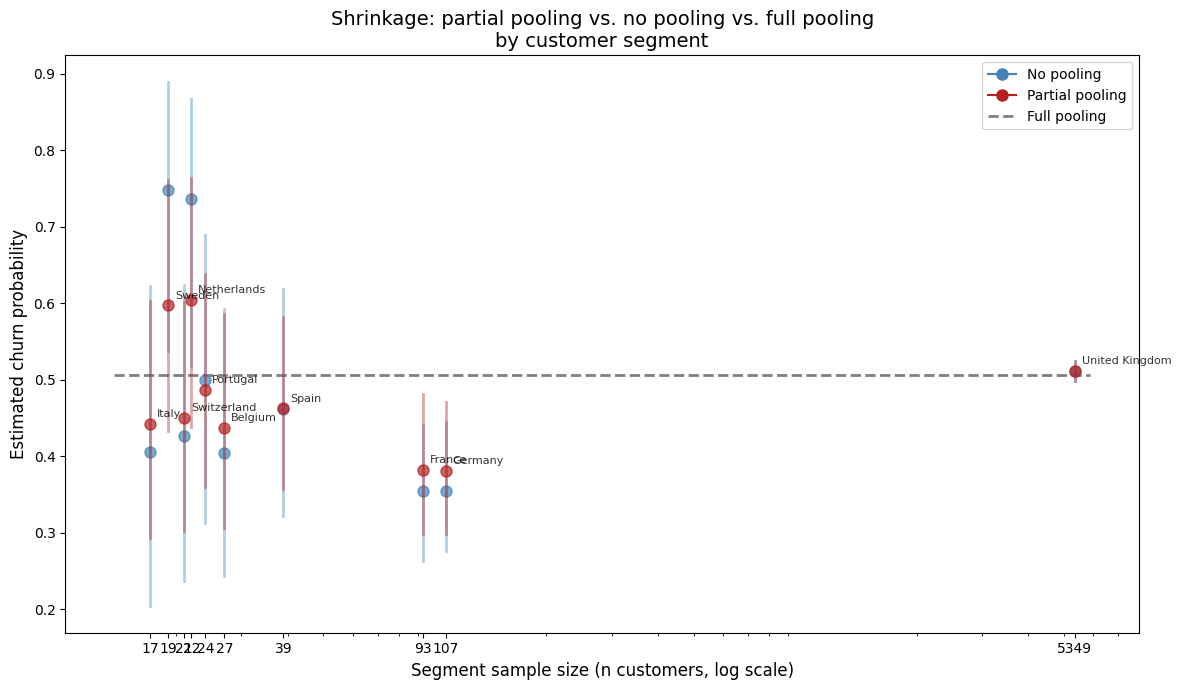

Shrinkage plot saved to figures/shrinkage_plot.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.hlines(fp_mean, seg_sizes.min() * 0.8, seg_sizes.max() * 1.1, colors="grey",
          linestyles="dashed", linewidth=2, label="Full pooling (global mean)")

for i, (n, name) in enumerate(zip(seg_sizes, seg_names)):
    ax.plot(n, np_means[i], "o", color="steelblue", alpha=0.7, markersize=8)
    ax.plot([n, n], [np_lo[i], np_hi[i]], color="steelblue", alpha=0.4, linewidth=2)
    ax.plot(n, pp_means[i], "o", color="firebrick", alpha=0.7, markersize=8)
    ax.plot([n, n], [pp_lo[i], pp_hi[i]], color="firebrick", alpha=0.4, linewidth=2)
    ax.annotate(name, (n, pp_means[i]), fontsize=8, alpha=0.8,
                textcoords="offset points", xytext=(5, 5))

ax.set_xscale("log")
ax.set_xticks(seg_sizes)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

legend_elements = [
    Line2D([0], [0], marker="o", color="steelblue", label="No pooling", markersize=8),
    Line2D([0], [0], marker="o", color="firebrick", label="Partial pooling", markersize=8),
    Line2D([0], [0], color="grey", linestyle="dashed", label="Full pooling", linewidth=2),
]
ax.legend(handles=legend_elements, loc="best")
ax.set_xlabel("Segment sample size (n customers, log scale)", fontsize=12)
ax.set_ylabel("Estimated churn probability", fontsize=12)
ax.set_title("Shrinkage: partial pooling vs. no pooling vs. full pooling\nby customer segment", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/shrinkage_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Shrinkage plot saved to figures/shrinkage_plot.png")

## 3. Tau posterior

Tau is the between-segment standard deviation on the log-odds scale:
- **tau < 0.5:** modest heterogeneity — partial pooling reduces to near full pooling
- **tau ≈ 1:** meaningful heterogeneity — segments differ by ~1 SD on log-odds (~18pp difference in churn probability)
- **tau > 2:** strong heterogeneity — segments are nearly independent, partial pooling adds little over no pooling

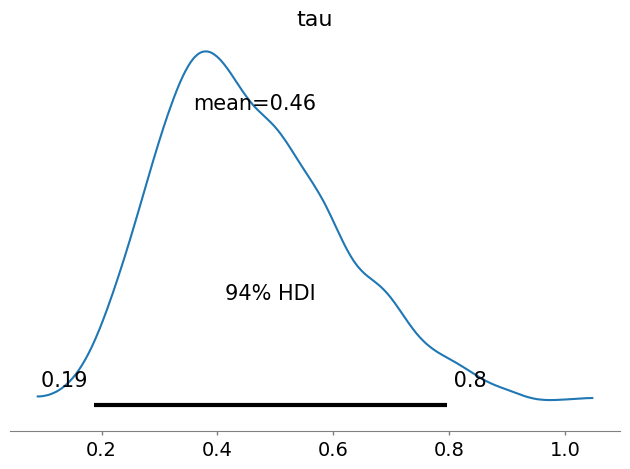

tau posterior median: 0.439
tau 94% HDI: [0.209, 0.832]
Mean churn probability: 49.1%
At this mean, tau = 0.439 corresponds to a 11pp difference in churn probability between segments ±0.5 SD from the mean.
Interpretation: modest heterogeneity — partial pooling reduces to near full pooling.


In [5]:
az.plot_posterior(trace_partial, var_names=["tau"], hdi_prob=0.94)
plt.tight_layout()
plt.show()

tau_samples = trace_partial.posterior["tau"].values.flatten()
tau_median = np.median(tau_samples)
tau_hdi = np.percentile(tau_samples, [3, 97])
mu_samples = trace_partial.posterior["mu"].values.flatten()
mu_median = np.median(mu_samples)

# Convert tau to percentage point difference at the mean churn probability
p_mean = expit(mu_median)
p_high = expit(mu_median + tau_median / 2)
p_low = expit(mu_median - tau_median / 2)
pp_diff = (p_high - p_low) * 100

print(f"tau posterior median: {tau_median:.3f}")
print(f"tau 94% HDI: [{tau_hdi[0]:.3f}, {tau_hdi[1]:.3f}]")
print(f"Mean churn probability: {p_mean:.1%}")
print(f"At this mean, tau = {tau_median:.3f} corresponds to a {pp_diff:.0f}pp difference in churn probability between segments ±0.5 SD from the mean.")
if tau_median < 0.5:
    print("Interpretation: modest heterogeneity — partial pooling reduces to near full pooling.")
elif tau_median < 2:
    print("Interpretation: meaningful heterogeneity — segments differ on log-odds scale.")
else:
    print("Interpretation: strong heterogeneity — segments are nearly independent.")

## 4. Model comparison via LOO-CV

LOO-CV (Leave-One-Out Cross-Validation) via PSIS (Pareto-Smoothed Importance Sampling) is the standard Bayesian model comparison metric. Higher ELPD (Expected Log Predictive Density) is better. Partial pooling should outperform both extremes, especially on small segments. If it does not outperform no pooling, the segments are genuinely independent and the hierarchical structure is not supported by the data.

In [6]:
print("Computing LOO for partial pooling...")
loo_partial = az.loo(trace_partial)
print("Computing LOO for no pooling...")
loo_no_pool = az.loo(trace_no_pool)
print("Computing LOO for full pooling...")
loo_full = az.loo(trace_full)

comparison = az.compare({
    "partial_pooling": trace_partial,
    "no_pooling": trace_no_pool,
    "full_pooling": trace_full,
}, ic="loo")
print(comparison.to_string())

Computing LOO for partial pooling...
Computing LOO for no pooling...
Computing LOO for full pooling...
                 rank     elpd_loo      p_loo  elpd_diff    weight        se       dse  warning scale
partial_pooling     0 -4065.905433   8.060588   0.000000  0.253625  4.573448  0.000000    False   log
no_pooling          1 -4067.555920  11.651318   1.650487  0.517242  6.253564  2.196107    False   log
full_pooling        2 -4074.478798   1.008940   8.573366  0.229133  1.251761  4.372509    False   log


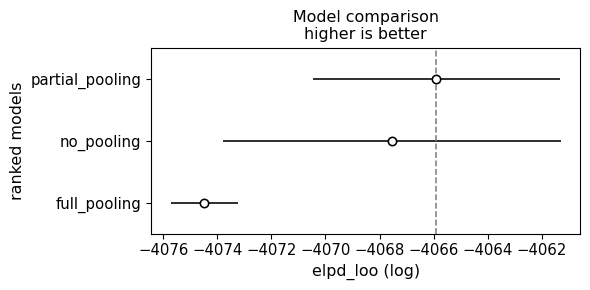

LOO comparison plot rendered.


In [7]:
az.plot_compare(comparison)
plt.tight_layout()
plt.show()
print("LOO comparison plot rendered.")

## 5. Summary

In [8]:
print("=== Phase 4 Summary ===")
print(f"tau posterior median: {tau_median:.3f} (94% HDI: [{tau_hdi[0]:.3f}, {tau_hdi[1]:.3f}])")
print(f"Mean churn probability: {p_mean:.1%}")
print(f"Between-segment spread: {pp_diff:.0f}pp difference in churn probability")
print(f"Best model by LOO: {comparison.index[0]} (ELPD: {comparison.iloc[0]['elpd_loo']:.1f})")
print(f"ELPD difference (partial vs full): {comparison.loc['partial_pooling', 'elpd_diff']:.1f}")
print(f"ELPD difference (partial vs no): {comparison.loc['partial_pooling', 'elpd_diff'] - comparison.loc['no_pooling', 'elpd_diff']:.1f}")
print("Results complete.")

=== Phase 4 Summary ===
tau posterior median: 0.439 (94% HDI: [0.209, 0.832])
Mean churn probability: 49.1%
Between-segment spread: 11pp difference in churn probability
Best model by LOO: partial_pooling (ELPD: -4065.9)
ELPD difference (partial vs full): 0.0
ELPD difference (partial vs no): -1.7
Results complete.
